In [1]:
import pandas as pd
import numpy as np
from autogluon.tabular import TabularDataset, TabularPredictor
import seaborn as sns
import matplotlib.pyplot as plt
from sdv.metadata import SingleTableMetadata
from sdv.single_table import CTGANSynthesizer

In [2]:
odroid1 = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/odroid1_firefox_onscreen.csv")
odroid2 = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/odroid2_firefox_onscreen.csv")
odroid3 = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/odroid3_firefox_onscreen.csv")
odroid4 = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/odroid4_firefox_onscreen.csv")

In [3]:
rpi4a = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/rpi-4a_chrome_onscreen.csv")
rpi8a = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/rpi-8a_chrome_onscreen.csv")
rpi8b = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/rpi-8b_chrome_onscreen.csv")
rpi8c = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/rpi-8c_chrome_onscreen.csv")
rpi8d = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/rpi-8d_chrome_onscreen.csv")

In [4]:
df = pd.concat([odroid1[:2000], odroid2[:2000], odroid3[:2000], odroid4[:2000], rpi4a[:2000], rpi8a[:2000], rpi8b[:2000], rpi8c[:2000], rpi8d[:2000]])
df = df.sample(frac=1).reset_index(drop=True)

In [5]:
len(df)

18000

In [6]:
train_data = df.head(8000)
test_data = df.tail(8000)

In [7]:
train_data

,label,Feature 0,Feature 1,Feature 2,Feature 3,Feature 4,Feature 5,Feature 6
0,odroid2,163.0,181.0,154.0,169.0,13.0,166.0,333.0
1,rpi-8c,17.2,15.5,1402.7,18.4,13.3,18.0,17.9
2,odroid3,167.0,174.0,169.0,171.0,169.0,171.0,165.0
3,rpi-8c,227.5,450.5,14.5,233.2,467.2,27.8,225.4
4,rpi-8d,18.1,11.6,112.0,1705.1,18.0,17.4,200.5
...,...,...,...,...,...,...,...,...
7995,rpi-8c,15.4,17.9,17.7,18.2,17.9,18.0,17.8
7996,odroid3,167.0,169.0,170.0,170.0,168.0,171.0,167.0
7997,rpi-4a,21.2,18.6,1158.5,421.6,16.2,19.1,18.2
7998,odroid1,164.0,167.0,167.0,13.0,152.0,335.0,166.0


In [8]:
test_data

,label,Feature 0,Feature 1,Feature 2,Feature 3,Feature 4,Feature 5,Feature 6
10000,rpi-8d,15.9,20.2,16.4,17.8,571.0,18.0,18.0
10001,odroid1,6.0,160.0,6.0,325.0,331.0,169.0,166.0
10002,rpi-4a,12.8,19.4,965.5,631.1,21.0,17.2,19.7
10003,rpi-8d,15.5,18.1,17.1,19.1,948.1,17.5,18.0
10004,rpi-8c,51.0,2659.2,41.0,29.2,606.1,16.3,16.6
...,...,...,...,...,...,...,...,...
17995,odroid3,166.0,173.0,169.0,174.0,169.0,172.0,168.0
17996,rpi-8d,20.3,14.0,17.5,17.7,961.8,19.3,16.8
17997,odroid2,164.0,180.0,156.0,172.0,170.0,171.0,170.0
17998,odroid4,170.0,171.0,174.0,171.0,171.0,172.0,172.0


In [9]:
predictor = TabularPredictor.load("ag-20240916_042643")

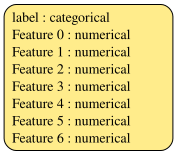

In [10]:
metadata = SingleTableMetadata()
metadata.detect_from_dataframe(test_data)
metadata.visualize()

In [11]:
vae_results = pd.DataFrame(columns=['epoch', 'accuracy', 'balanced_accuracy', 'mcc'])

for i in range(100,1100,100):
    print(i)
    synthesizer = CTGANSynthesizer(
        metadata, 
        enforce_rounding=True,
        epochs=i
    )
    
    synthesizer.fit(test_data)
    synthetic_data = synthesizer.sample(num_rows=1000)
    
    y_pred = predictor.predict(synthetic_data)
    y_pred_proba = predictor.predict_proba(synthetic_data)
    results = predictor.evaluate(synthetic_data)
    
    new_results = {'epoch':i, 'accuracy':results['accuracy'], 'balanced_accuracy':results['balanced_accuracy'], 'mcc':results['mcc']}
    vae_results.loc[len(vae_results)] = (new_results)

100


/home/zac/miniconda3/envs/ag/lib/python3.10/site-packages/sdv/single_table/base.py:97: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(
/home/zac/miniconda3/envs/ag/lib/python3.10/site-packages/dask/dataframe/__init__.py:42: FutureWarning: 
Dask dataframe query planning is disabled because dask-expr is not installed.

You can install it with `pip install dask[dataframe]` or `conda install dask`.
This will raise in a future version.

  warnings.warn(msg, FutureWarning)


200
300
400
500
600
700
800
900
1000


# VAE Attack accuracy with various training epochs

<Axes: xlabel='epoch', ylabel='value'>

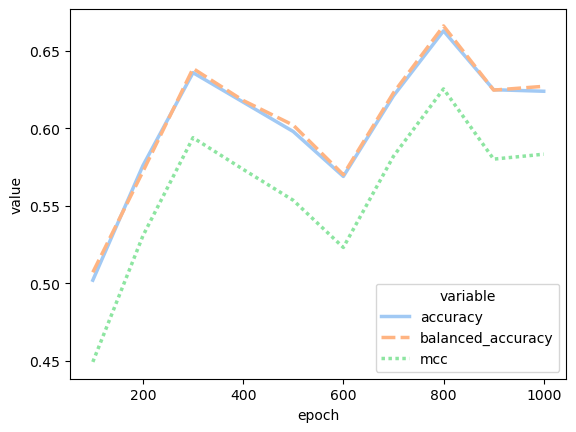

In [12]:
sns.lineplot(data=pd.melt(vae_results, ['epoch']), x='epoch', y='value', style="variable", hue='variable', palette="pastel", linewidth=2.5)

## Which devices are most vulnerable to this attack?

In [13]:
devices_fooled = pd.DataFrame(columns=['device', 'accuracy'])
for device in list(y_pred.unique()):
    devices_fooled.loc[len(devices_fooled)] = {'device': device, 'accuracy': 0.0}

for pred, label in zip(list(y_pred), list(synthetic_data['label'])):
    if pred == label:
        devices_fooled.loc[devices_fooled['device'] == pred, 'accuracy'] += 1

for device in list(y_pred.unique()):
    devices_fooled.loc[devices_fooled['device'] == device, 'accuracy'] /= list(synthetic_data['label']).count(device)

devices_fooled['accuracy'] *= 100

<Axes: xlabel='device', ylabel='accuracy'>

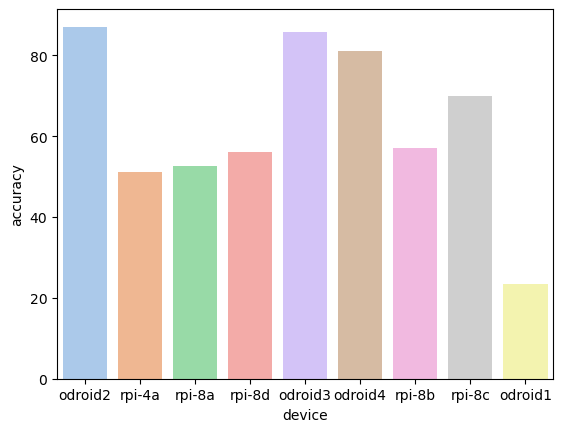

In [14]:
sns.barplot(data=devices_fooled, x='device', y='accuracy', hue='device', palette="pastel", legend=False, linewidth=2.5)

# Adding adversarial data into the training set

In [36]:
bad_train = pd.DataFrame()
synthetic_data = pd.DataFrame()
for i in range(100,1100,100):
    print(i)
    synthesizer = CTGANSynthesizer(
        metadata, 
        enforce_rounding=True,
        epochs=i
    )
    
    synthesizer.fit(train_data)
    synthetic_data = synthesizer.sample(num_rows=500)
    bad_train = pd.concat([synthetic_data, bad_train])
bad_train['label'] = 'bad'

100
200
300
400
500
600
700
800
900
1000


In [37]:
bad_train

,label,Feature 0,Feature 1,Feature 2,Feature 3,Feature 4,Feature 5,Feature 6
0,bad,158.7,167.7,170.5,166.9,166.3,167.6,169.1
1,bad,161.9,168.9,168.0,172.7,166.9,169.7,164.6
2,bad,240.5,222.9,204.8,444.8,27.3,21.4,224.6
3,bad,171.7,185.3,158.5,170.9,169.0,9.5,164.0
4,bad,162.9,8.5,7.9,80.1,320.1,171.2,170.7
...,...,...,...,...,...,...,...,...
495,bad,12.3,14.1,438.8,892.6,348.7,871.9,14.6
496,bad,210.1,233.5,455.4,429.5,221.3,445.8,225.5
497,bad,165.2,183.1,160.6,168.3,170.1,169.4,174.9
498,bad,223.1,240.0,239.6,229.6,223.5,22.9,15.6


In [29]:
good_train = train_data.copy()
good_train['label'] = 'good'

In [30]:
good_train

,label,Feature 0,Feature 1,Feature 2,Feature 3,Feature 4,Feature 5,Feature 6
0,good,163.0,181.0,154.0,169.0,13.0,166.0,333.0
1,good,17.2,15.5,1402.7,18.4,13.3,18.0,17.9
2,good,167.0,174.0,169.0,171.0,169.0,171.0,165.0
3,good,227.5,450.5,14.5,233.2,467.2,27.8,225.4
4,good,18.1,11.6,112.0,1705.1,18.0,17.4,200.5
...,...,...,...,...,...,...,...,...
7995,good,15.4,17.9,17.7,18.2,17.9,18.0,17.8
7996,good,167.0,169.0,170.0,170.0,168.0,171.0,167.0
7997,good,21.2,18.6,1158.5,421.6,16.2,19.1,18.2
7998,good,164.0,167.0,167.0,13.0,152.0,335.0,166.0


In [19]:
bad_test = pd.DataFrame()
synthetic_data = pd.DataFrame()
for i in range(100,1100,100):
    print(i)
    synthesizer = CTGANSynthesizer(
        metadata, 
        enforce_rounding=True,
        epochs=i
    )
    
    synthesizer.fit(test_data[:4000])
    synthetic_data = synthesizer.sample(num_rows=100)
    bad_test = pd.concat([synthetic_data, bad_test])
bad_test['label'] = 'bad'

100
200
300
400
500
600
700
800
900
1000


In [20]:
good_test = test_data.copy()
good_test = good_test[4000:5000]
good_test['label'] = 'good'

In [38]:
good_bad_train = pd.concat([good_train, bad_train], ignore_index=True)

In [39]:
good_bad_test = pd.concat([good_test, bad_test], ignore_index=True)

In [40]:
predictor = TabularPredictor(label='label').fit(good_bad_train, num_gpus=1, presets='medium_quality')
y_pred = predictor.predict(good_bad_test)
y_pred_proba = predictor.predict_proba(good_bad_test)
results = predictor.evaluate(good_bad_test)

No path specified. Models will be saved in: "AutogluonModels/ag-20240918_030243"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.1.1
Python Version:     3.10.13
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #45-Ubuntu SMP PREEMPT_DYNAMIC Fri Aug 30 12:02:04 UTC 2024
CPU Count:          12
Memory Avail:       17.31 GB / 23.34 GB (74.2%)
Disk Space Avail:   248.12 GB / 341.37 GB (72.7%)
Presets specified: ['medium_quality']
Beginning AutoGluon training ...
AutoGluon will save models to "AutogluonModels/ag-20240918_030243"
Train Data Rows:    13000
Train Data Columns: 7
Label Column:       label
AutoGluon infers your prediction problem is: 'binary' (because only two unique label-values observed).
	2 unique label values:  ['good', 'bad']
	If 'binary' is not the correct problem_type, please manually specify the problem_type parameter during Predictor init (You may specify problem_type as one of: ['binary', 

[1000]	valid_set's binary_error: 0.0623077
[2000]	valid_set's binary_error: 0.0546154


	0.9492	 = Validation score   (accuracy)
	2.16s	 = Training   runtime
	0.01s	 = Validation runtime
Fitting model: LightGBM ...
	Training LightGBM with GPU, note that this may negatively impact model quality compared to CPU training.
[LightGBM] [Fatal] GPU Tree Learner was not enabled in this build.
Please recompile with CMake option -DUSE_GPU=1
	0.9677	 = Validation score   (accuracy)
	0.75s	 = Training   runtime
	0.0s	 = Validation runtime
Fitting model: RandomForestGini ...


[1000]	valid_set's binary_error: 0.0338462


	0.9485	 = Validation score   (accuracy)
	0.49s	 = Training   runtime
	0.04s	 = Validation runtime
Fitting model: RandomForestEntr ...
	0.9515	 = Validation score   (accuracy)
	0.4s	 = Training   runtime
	0.04s	 = Validation runtime
Fitting model: CatBoost ...
	Training CatBoost with GPU, note that this may negatively impact model quality compared to CPU training.
	0.9492	 = Validation score   (accuracy)
	12.47s	 = Training   runtime
	0.0s	 = Validation runtime
Fitting model: ExtraTreesGini ...
	0.9515	 = Validation score   (accuracy)
	0.33s	 = Training   runtime
	0.03s	 = Validation runtime
Fitting model: ExtraTreesEntr ...
	0.9523	 = Validation score   (accuracy)
	0.32s	 = Training   runtime
	0.04s	 = Validation runtime
Fitting model: NeuralNetFastAI ...
/home/zac/miniconda3/envs/ag/lib/python3.10/site-packages/fastai/learner.py:53: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is p

In [41]:
adersary_accuracy_after_training = pd.DataFrame(columns=['epoch', 'accuracy (AD)'])
for i in range(100,1100,100):
    adersary_accuracy_after_training.loc[len(adersary_accuracy_after_training)] = {'epoch':i, 'accuracy (AD)':0.0}

for i, (pred, label) in enumerate(zip(list(y_pred), list(good_bad_test['label']))):
    if pred == 'good' and label == 'bad':
        bucket_index = (i // 100 * 100) - 900
        adersary_accuracy_after_training.loc[adersary_accuracy_after_training['epoch'] == bucket_index, 'accuracy (AD)'] += 1


for device in list(y_pred.unique()):
    devices_fooled.loc[devices_fooled['device'] == device, 'accuracy'] /= list(synthetic_data['label']).count(device)

adersary_accuracy_after_training['accuracy (no AD)'] = vae_results['accuracy'] * 100

In [42]:
adersary_accuracy_after_training

,epoch,accuracy (AD),accuracy (no AD)
0,100,5.0,50.2
1,200,7.0,57.6
2,300,2.0,63.6
3,400,8.0,61.7
4,500,4.0,59.8
5,600,7.0,56.9
6,700,7.0,62.1
7,800,2.0,66.3
8,900,4.0,62.5
9,1000,10.0,62.4


<Axes: xlabel='epoch', ylabel='value'>

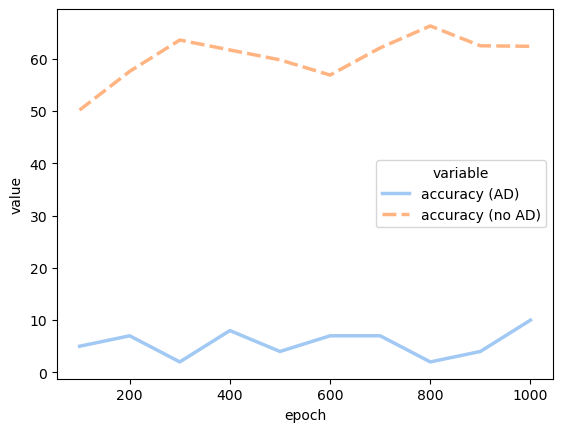

In [43]:
sns.lineplot(data=pd.melt(adersary_accuracy_after_training, ['epoch']), x='epoch', y='value', style="variable", hue='variable', palette="pastel", linewidth=2.5)